In [1]:
%load_ext autoreload
%autoreload 2

import sys, pathlib
p = pathlib.Path.cwd()
for q in (p, *p.parents):
    s = q / "src" / "ftbp"   # <- change "ftbp" if you rename the package
    if s.exists():
        sys.path.insert(0, str(s.parent))  # add .../src
        break
else:
    raise RuntimeError("src/ftbp not found")

In [2]:
import numpy as np
import pandas as pd
import itertools
from math import comb
from scipy.optimize import brentq
from scipy.stats import norm, cauchy, uniform
from ftbp.estimators import estimate_theta, estimate_sigma
from ftbp.wald import *

In [3]:
### the gap experiment
from tqdm import tqdm
# 50 to 4000
ns = [50 + i * 200 for i in range(21)]
# ns = [100]
M = 100
seeds = [53 + i for i in range(M)]
dists = [norm, cauchy, uniform]
delta = 1.345

all_results = []
for n in ns:
    for dist in dists:
        for seed in tqdm(seeds):
            np.random.seed(seed)
            phi0 = 0
            while phi0 == 0:
                if dist == uniform:
                    x = dist.rvs(size=n) + 0.5
                else:
                    sign = np.random.choice([-1, 1])
                    x = dist.rvs(size=n) + 1 * sign
                phi0 = wald_test(x, delta=delta, null=True)
                if phi0 == 1:
                    grid = np.linspace(np.min(x) - 20, np.max(x) + 20, 1000)
                    bp_ub_power = bound_power_upper(x, delta=delta, null=True)
                    bp_lb_power = bound_power_lower(x, delta=delta, null=True)
                    # print("UB:", bp_ub_power, "LB:", bp_lb_power)

            all_results.append({
                'n': n,
                'dist': getattr(dist, 'name', dist.__class__.__name__),
                'seed': seed,
                'power_lb': bp_lb_power,
                'power_ub': bp_ub_power,
            })

df = pd.DataFrame(all_results)

100%|██████████| 100/100 [00:50<00:00,  1.98it/s]


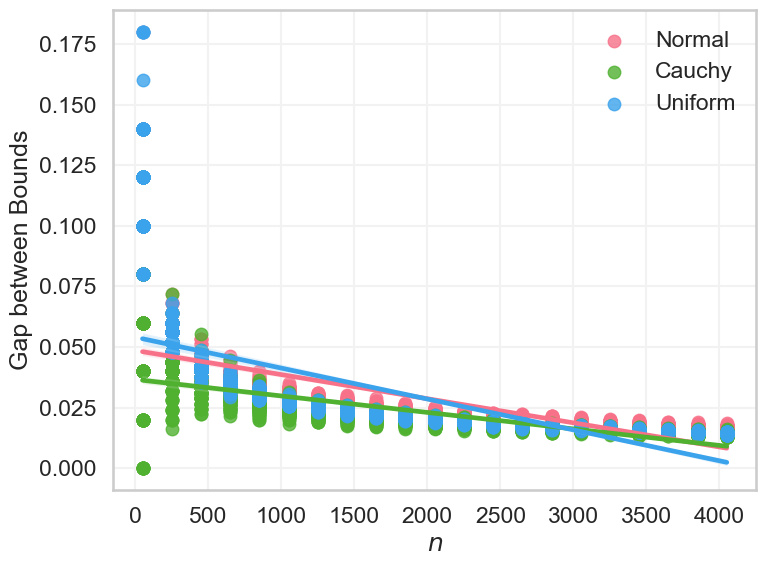

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# 1) pick your style & context
sns.set_style("whitegrid")    # e.g. “darkgrid”, “ticks”, “white”
sns.set_context("talk")       # options: “paper”, “notebook”, “talk”, “poster”
palette = sns.color_palette("husl", 3)
sns.set_style("whitegrid", {'grid.color': '#F2F2F2'})

# 2) fit 
df['gap'] = df['power_ub'] - df['power_lb']
df['gap_ratio'] = df['gap'] / df['n']

model = smf.ols('gap_ratio ~ n', data=df[df['dist'] == 'norm']).fit()
m_est = model.params['n']

# 3) build the scatter + regression line
plt.figure(figsize=(8,6))
sns.regplot(
    x='n', 
    y='gap_ratio', 
    data=df[df['dist'] == 'norm'],
    color=palette[0], 
    label=f'Normal',
    scatter=True,
    ci=95,
    scatter_kws=dict(rasterized=True)
)

model = smf.ols('gap_ratio ~ n', data=df[df['dist'] == 'cauchy']).fit()
# print(model.params.index)
m_est = model.params['n']
sns.regplot(
    x='n',
    y='gap_ratio',
    data=df[df['dist'] == 'cauchy'],
    color=palette[1],
    label=f'Cauchy',
    ci=95,
    scatter=True,
    scatter_kws=dict(rasterized=True)
)

model = smf.ols('gap_ratio ~ n', data=df[df['dist'] == 'uniform']).fit()
# print(model.params.index)
m_est = model.params['n']
sns.regplot(
    x='n',
    y='gap_ratio',
    data=df[df['dist'] == 'uniform'],
    color=palette[2],
    label=f'Uniform',
    ci=95,
    scatter=True,
    scatter_kws=dict(rasterized=True)
)

# 4) polish labels & legend
plt.xlabel("$n$")
plt.ylabel("Gap between Bounds")
# plt.title("Scaling of BP_reject bound gap with $n$ (normal)")
plt.legend(loc='best', ncols=1, frameon=False)
plt.tight_layout()
plt.savefig("gap_huber_restricted_ratio_new_scatter.pdf", bbox_inches='tight')


In [5]:
### the gap experiment
from tqdm import tqdm
ns = [500, 1000, 2000]
# ns = [100]
M = 100
seeds = [53 + i for i in range(M)]
dists = [norm, cauchy]
alternatives = [-2, -1.5, -1, -.5, -.25, -.1, 0, .1, .25, .5, 1, 1.5, 2]
loss_type = 'huber'  # or 'logcosh'
if loss_type == 'huber':
    delta = 1.345
elif loss_type == 'logcosh':
    delta = 1.2047
elif loss_type == 'concordant':
    delta = 1.4811

all_results = []
for alternative in alternatives:
    for n in ns:
        for dist in dists:
            for seed in tqdm(seeds):
                np.random.seed(seed)
                phi0 = 0
                while phi0 == 0:
                    # sign = np.random.choice([-1, 1])
                    x = dist.rvs(size=n) + alternative
                    phi0 = wald_test(x, null=True, delta=delta, loss_type=loss_type)
                    if phi0 == 1:
                        bp_ub_power = bound_power_upper(x, null=True, delta=delta, loss_type=loss_type)
                        bp_lb_power = bound_power_lower(x, null=True, delta=delta, loss_type=loss_type)

                all_results.append({
                    'n': n,
                    'dist': getattr(dist, 'name', dist.__class__.__name__),
                    'seed': seed,
                    'power_lb': bp_lb_power,
                    'power_ub': bp_ub_power,
                    'alternative': alternative
                })

df = pd.DataFrame(all_results)

100%|██████████| 100/100 [00:14<00:00,  6.82it/s]


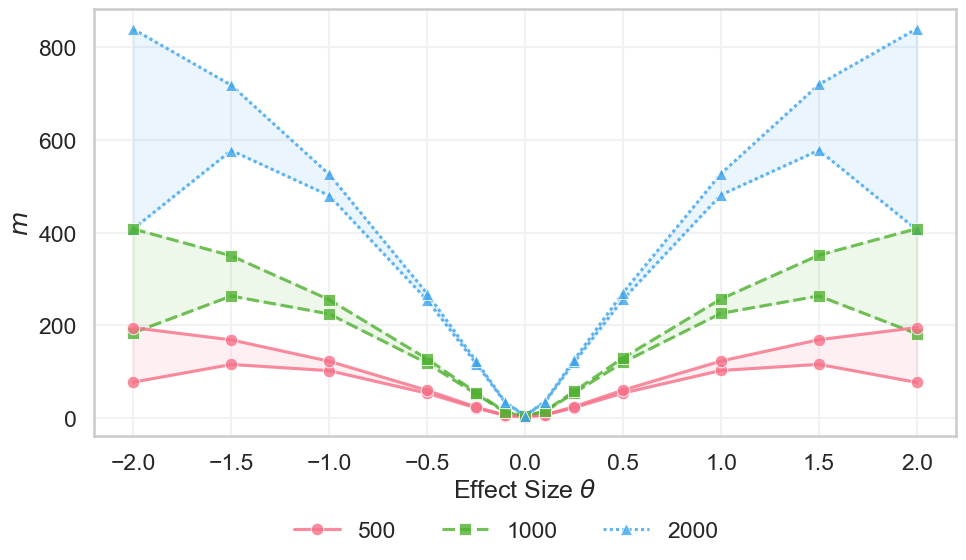

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# assume df_avg already exists from previous steps:
#   columns=['n','Effect Size','Lower Bound of Power','Upper Bound of Power']
sns.set_context('talk')
sns.set_style("whitegrid", {'grid.color': '#F2F2F2'})  # e.g. “darkgrid”, “ticks”, “white”
palette = sns.color_palette("husl", 3)

df_normal = df[df['dist'] == 'norm']

# 1. Melt to long form
df_avg = (
    df_normal
    .groupby(['n', 'alternative'], as_index=False)
    .agg({'power_ub': 'mean', 'power_lb': 'mean'})
)

# 3. Rename for paper‐friendly labels
df_avg = df_avg.rename(columns={
    'alternative': 'Effect Size',
    'power_ub':    'Upper Bound of BP',
    'power_lb':    'Lower Bound of BP'
})

marker_map = {500: 'o', 1000: 's', 2000: '^'}

# 3. Single‐plot
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df_avg,
    x='Effect Size', y='Lower Bound of BP',
    hue='n',                 # color by bound type
    style='n',            # line style by n
    markers=marker_map,
    palette=palette,
    legend='full',
    alpha=0.8,
)

sns.lineplot(
    data=df_avg,
    x='Effect Size', y='Upper Bound of BP',
    hue='n',                 # color by bound type
    style='n',            # line style by n
    markers=marker_map,
    palette=palette,
    legend=False,
    alpha=0.8,
)

i = -1
for n_val in [500, 1000, 2000]:
    i += 1
    sub = df_avg[df_avg['n'] == n_val]
    ax.fill_between(sub['Effect Size'],
                    sub['Lower Bound of BP'],
                    sub['Upper Bound of BP'],
                    alpha=0.1, color=palette[i])

plt.xlabel(r'Effect Size $\theta$')
plt.ylabel(r'$m$')
ax.legend(loc='upper center', bbox_to_anchor=(0.478, -0.15), ncols=7, frameon=False)
plt.tight_layout()
# plt.show()
plt.savefig('bp_reject_restricted.pdf', bbox_inches='tight')

In [7]:
df_avg

,n,Effect Size,Upper Bound of BP,Lower Bound of BP
0,500,-2.00,195.39,77.79
1,500,-1.50,168.91,115.93
2,500,-1.00,122.84,102.55
3,500,-0.50,59.97,53.79
4,500,-0.25,24.09,22.00
5,500,-0.10,6.28,5.69
6,500,0.00,3.41,3.14
7,500,0.10,7.19,6.64
8,500,0.25,24.82,22.75
9,500,0.50,60.58,54.27


In [ ]:
marker_map = {500: 'o', 1000: 's', 2000: '^'}

# make y-axis to bound/n, fraction
df_avg['Lower Bound of BP ratio'] = df_avg['Lower Bound of BP'] / df_avg['n']
df_avg['Upper Bound of BP ratio'] = df_avg['Upper Bound of BP'] / df_avg['n']

# 3. Single‐plot
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df_avg,
    x='Effect Size', y='Lower Bound of BP ratio',
    hue='n',                 # color by bound type
    style='n',            # line style by n
    markers=marker_map,
    palette=palette,
    legend='full',
    alpha=0.8,
)

sns.lineplot(
    data=df_avg,
    x='Effect Size', y='Upper Bound of BP ratio',
    hue='n',                 # color by bound type
    style='n',            # line style by n
    markers=marker_map,
    palette=palette,
    legend=False,
    alpha=0.8,
)

i = -1
for n_val in [500, 1000, 2000]:
    i += 1
    sub = df_avg[df_avg['n'] == n_val]
    ax.fill_between(sub['Effect Size'],
                    sub['Lower Bound of BP ratio'],
                    sub['Upper Bound of BP ratio'],
                    alpha=0.1, color=palette[i])

plt.xlabel(r'Effect Size $\theta$')
plt.ylabel('Breakdown Point of Rejection')
ax.legend(loc='upper center', bbox_to_anchor=(0.478, -0.15), ncols=7, frameon=False)
plt.tight_layout()
# plt.show()
plt.savefig('bp_reject_restricted_ratio.pdf', bbox_inches='tight')